# Interactive Linear Regression with Ridge & Lasso
Explore ordinary least squares (OLS), Ridge, and Lasso regression on synthetic data. Adjust parameters and see how the fit, coefficients, and error change.

In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown


In [11]:
def plot_regression(model_type, alpha, n_samples, noise, seed):
    """Generate data, fit selected regression, and plot results."""
    # 1. Data generation
    np.random.seed(seed)
    X = np.random.rand(n_samples, 1)
    y = 1 + 0.5 * X[:, 0] + np.random.randn(n_samples) * noise

    # 2. Model selection
    if model_type == 'OLS':
        model = LinearRegression()
    elif model_type == 'Ridge':
        model = Ridge(alpha=alpha)
    else:  # Lasso
        # if alpha == 0 we just use OLS under the hood
        if alpha == 0:
            model = LinearRegression()
        else:
            model = Lasso(alpha=alpha, max_iter=100000)

    # 3. Fit
    model.fit(X, y)

    # 4. Predictions for plotting
    X_line = np.linspace(0, 1, 100).reshape(-1, 1)
    y_line = model.predict(X_line)

    # 5. Metrics
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    intercept = model.intercept_
    slope = model.coef_[0]

    # 6. Plotting
    plt.figure(figsize=(6, 6))
    plt.scatter(X, y, c='blue', edgecolors='white', label='Data')
    plt.plot(X_line, y_line, c='red', linewidth=2, label='Fit')
    plt.title(
        f"{model_type} Regression  |  α={alpha:.2f}\n"
        f"Intercept={intercept:.2f},  Slope={slope:.2f},  MSE={mse:.3f}"
    )
    plt.xlabel('x₁')
    plt.ylabel('y')
    plt.legend()
    plt.ylim(y.min() - 0.5, y.max() + 0.5)
    plt.show()


In [12]:
interact(
    plot_regression,
    model_type=Dropdown(
        options=['OLS', 'Ridge', 'Lasso'],
        value='OLS',
        description='Model:'
    ),
    alpha=FloatSlider(
        min=0.0, max=10.0, step=0.1, value=1.0,
        description='α:'
    ),
    n_samples=IntSlider(
        min=10, max=200, step=10, value=50,
        description='Samples:'
    ),
    noise=FloatSlider(
        min=0.0, max=1.0, step=0.01, value=0.1,
        description='Noise:'
    ),
    seed=IntSlider(
        min=0, max=100, step=1, value=0,
        description='Seed:'
    )
)


interactive(children=(Dropdown(description='Model:', options=('OLS', 'Ridge', 'Lasso'), value='OLS'), FloatSli…

<function __main__.plot_regression(model_type, alpha, n_samples, noise, seed)>

## From Scratch Implementation

alpha= 0.0 -> intercept=1.022, slope=0.454, ridge_loss=0.008
alpha= 1.0 -> intercept=1.043, slope=0.408, ridge_loss=0.174
alpha=10.0 -> intercept=1.135, slope=0.212, ridge_loss=0.463


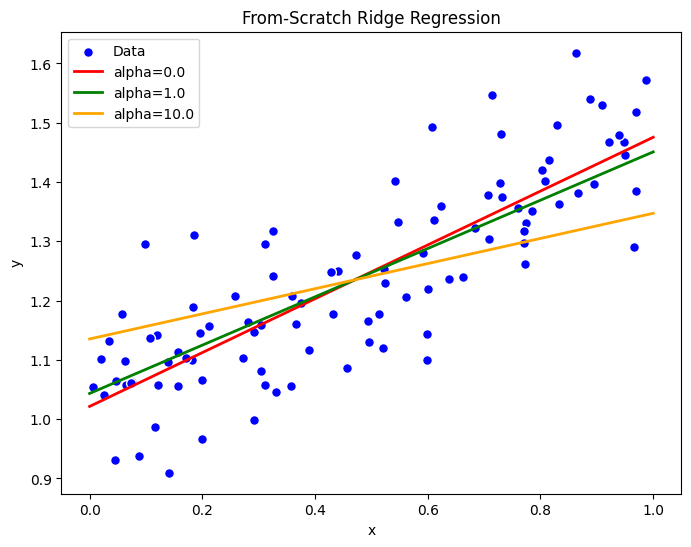

In [10]:
# ----------------------------
# 1. Data generation
# ----------------------------
np.random.seed(42)
n_samples = 100
X = np.random.rand(n_samples, 1)           # feature matrix (100×1)
y_true = 1 + 0.5 * X[:, 0]                 # underlying line: y = 1 + 0.5 x
noise = np.random.randn(n_samples) * 0.1
y = y_true + noise                         # noisy observations

# Add a column of ones for the intercept term
X_b = np.hstack([np.ones((n_samples, 1)), X])  # shape (100×2)

# ----------------------------
# 2. Closed-form Ridge implementation
# ----------------------------
def ridge_closed_form(X, y, alpha):
    """
    Solve for w in ridge regression:
      w = (X^T X + alpha * I)^{-1} X^T y
    
    Note:
    - X should include a column of ones for the bias term.
    - alpha >= 0 is the L2 regularization strength.
    - We do NOT regularize the bias term: set its penalty to zero.
    """
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0  # do not penalize intercept
    # compute (X^T X + alpha * I)
    A = X.T.dot(X) + alpha * I
    b = X.T.dot(y)
    w = np.linalg.inv(A).dot(b)
    return w  # shape (2,)

# ----------------------------
# 3. Define loss for monitoring
# ----------------------------
def mse_loss(X, y, w):
    """Mean squared error on data (no regularization)."""
    preds = X.dot(w)
    return np.mean((y - preds) ** 2)

def ridge_loss(X, y, w, alpha):
    """
    MSE + alpha * sum(weights^2)
    (we usually do not penalize the intercept, but if w[0] is bias, skip it)
    """
    mse = mse_loss(X, y, w)
    penalty = alpha * np.sum(w[1:] ** 2)
    return mse + penalty

# ----------------------------
# 4. Fit and compare
# ----------------------------
alphas = [0.0, 1.0, 10.0]  # 0.0 → ordinary least squares
fits = {}
for alpha in alphas:
    w = ridge_closed_form(X_b, y, alpha)
    loss = ridge_loss(X_b, y, w, alpha)
    fits[alpha] = (w, loss)
    print(f"alpha={alpha:4.1f} -> intercept={w[0]:.3f}, slope={w[1]:.3f}, ridge_loss={loss:.3f}")

# ----------------------------
# 5. Plot results
# ----------------------------
x_line = np.linspace(0, 1, 200)
X_line_b = np.vstack([np.ones_like(x_line), x_line]).T

plt.figure(figsize=(8, 6))
plt.scatter(X, y, c='blue', edgecolors='white', label='Data', s=50)

colors = ['red', 'green', 'orange']
for (alpha, (w, _)), c in zip(fits.items(), colors):
    y_line = X_line_b.dot(w)
    label = f"alpha={alpha:.1f}"
    plt.plot(x_line, y_line, c=c, lw=2, label=label)

plt.title("From-Scratch Ridge Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


---
**How to use:**
- **Model**: OLS ignores regularization; Ridge and Lasso apply L2 and L1 penalties, respectively.
- **α** (alpha): Regularization strength. Larger values → stronger shrinkage (coefficients closer to zero).
- **Samples**: Number of data points per run.
- **Noise**: Standard deviation of Gaussian noise added to y.
- **Seed**: Controls random data generation.

Experiment with α to see how Ridge vs. Lasso affects the slope!